In [2]:
! pip install gensim
! pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 87.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 107.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━

In [3]:
import torch
import pickle
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


import os
import re
import shutil
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import gensim.downloader as api
from collections import Counter

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
import dagshub
import mlflow
dagshub.init(repo_owner='thanwal', repo_name='Language-Translation', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=634a2927-8d70-477d-bfca-9135203a4742&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=0faf29d489b242069be0bf12de9ab6aebb787b363d9a20313a55dec5a1ff4dec




Accessing as thanwal

Initialized MLflow to track repo "thanwal/Language-Translation"

Repository thanwal/Language-Translation initialized!

In [7]:
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset from drive or upload to drive re-run

In [8]:
path = '/content/drive/My Drive/Language-Translation/'
csv='Sentence_pairs_in_English_Hindi.csv'
if os.path.exists(path):
    df = pd.read_csv(os.path.join(path, csv))
else:
     raise ValueError("Please go to your Drive that you mounted to Colab run time\n and create folder call Language-Translation and upload csv file!")

print(df.head())

                                   English  \
0                       Muiriel is 20 now.   
1                       Muiriel is 20 now.   
2  Education in this world disappoints me.   
3                       That won't happen.   
4                              I miss you.   

                                         Hindi  
0             म्यूरियल अब बीस साल की हो गई है।  
1                   म्यूरियल अब बीस साल की है।  
2  मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।  
3                              वैसा नहीं होगा।  
4                 मुझें तुम्हारी याद आ रही है।  


In [9]:
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
MIN_FREQ = 2
embedding_dim = 300

Function to create English embeddings

In [10]:
def create_English_embedding(df):
    English_train = df['English']
    English_word2vec = api.load('word2vec-google-news-300')

    English_train_sentences = [tokenize(x) for x in English_train]
    print(len(English_train_sentences))

    English_counter = Counter()
    for s in English_train_sentences:
        English_counter.update(s)

    English_valid_words = [w for w, count in English_counter.most_common() if count >= MIN_FREQ]

    English_word2idx = {tok: idx for idx, tok in enumerate(special_tokens)}
    for word in English_valid_words:
        English_word2idx[word] = len(English_word2idx)

    English_idx2word = {idx: word for word, idx in English_word2idx.items()}

    English_embedding_matrix = [np.zeros(embedding_dim), 
                                np.random.normal(scale=0.6, size=(embedding_dim,)),
                                np.zeros(embedding_dim),
                                np.zeros(embedding_dim)]

    for word in English_valid_words:
        if word in English_word2vec:
            English_embedding_matrix.append(English_word2vec[word])
        else:
            English_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    English_embedding_matrix = torch.from_numpy(np.array(English_embedding_matrix)).float()

    if len(English_embedding_matrix) == len(English_word2idx) == len(English_idx2word):
        print(len(English_word2idx))
        print(English_embedding_matrix.shape)

    del English_word2vec 
    gc.collect()

    return English_embedding_matrix, English_word2idx, English_idx2word

Function to create Hindi embeddings

In [11]:
def create_Hindi_embedding(df):
    Hindi_train = df['Hindi']
    Hindi_word2vec = api.load('fasttext-wiki-news-subwords-300')
    
    Hindi_train_sentences = [tokenize(x) for x in Hindi_train]
    print(len(Hindi_train_sentences))

    Hindi_counter = Counter()

    for s in Hindi_train_sentences:
        Hindi_counter.update(s)

    Hindi_valid_words = [w for w, count in Hindi_counter.most_common() if count >= MIN_FREQ]

    Hindi_word2idx={tok: idx for idx, tok in enumerate(special_tokens)}
    for word in Hindi_valid_words:
        Hindi_word2idx[word] = len(Hindi_word2idx)

    Hindi_idx2word = {idx: word for word, idx in Hindi_word2idx.items()}

    Hindi_embedding_matrix = [np.zeros(embedding_dim),
                            np.random.normal(scale=0.6, size=(embedding_dim,)),
                            np.zeros(embedding_dim),
                            np.zeros(embedding_dim)]

    for word in Hindi_valid_words:
        if word in Hindi_word2vec:
            Hindi_embedding_matrix.append(Hindi_word2vec[word])
        else:
            Hindi_embedding_matrix.append(np.random.normal(scale=0.6, size=(embedding_dim,)))

    Hindi_embedding_matrix = torch.from_numpy(np.array(Hindi_embedding_matrix)).float()

    if len(Hindi_embedding_matrix)==len(Hindi_word2idx)==len(Hindi_idx2word):
        print(len(Hindi_word2idx))
        print(Hindi_embedding_matrix.shape)

    del Hindi_word2vec 
    gc.collect()

    return Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word

Load saved Ebedding or create and save for re-run to drive 

In [12]:
saves_path='/content/drive/My Drive/Language-Translation/Saves'
if os.path.exists(saves_path):
    English_embedding_matrix = torch.load(os.path.join(saves_path, 'eng_emb.pt'))
    Hindi_embedding_matrix = torch.load(os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'rb') as f:
        English_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'rb') as f:
        Hindi_word2idx = pickle.load(f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'rb') as f:
        English_idx2word = pickle.load(f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'rb') as f:
        Hindi_idx2word = pickle.load(f)

    print(f"All files Loaded successfully Loaded")

else:
    English_embedding_matrix, English_word2idx, English_idx2word = create_English_embedding(df)
    Hindi_embedding_matrix, Hindi_word2idx, Hindi_idx2word = create_Hindi_embedding(df)


    os.makedirs(saves_path, exist_ok=True)

    torch.save(English_embedding_matrix, os.path.join(saves_path, 'eng_emb.pt'))
    torch.save(Hindi_embedding_matrix, os.path.join(saves_path, 'hin_emb.pt'))

    with open(os.path.join(saves_path, 'eng_word2idx.pkl'), 'wb') as f:
        pickle.dump(English_word2idx, f)

    with open(os.path.join(saves_path, 'hin_word2idx.pkl'), 'wb') as f:
        pickle.dump(Hindi_word2idx, f)

    with open(os.path.join(saves_path, 'eng_idx2word.pkl'), 'wb') as f:
        pickle.dump(English_idx2word, f)

    with open(os.path.join(saves_path, 'hin_idx2word.pkl'), 'wb') as f:
        pickle.dump(Hindi_idx2word, f)

    print(f"All files saved successfully to: {saves_path}")

All files Loaded successfully Loaded


Split data into Train, Test, Val

In [13]:
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

finding max lenght for data sample

99% of English sentences are shorter than: 28.0
99% of Hindi sentences are shorter than: 28.0


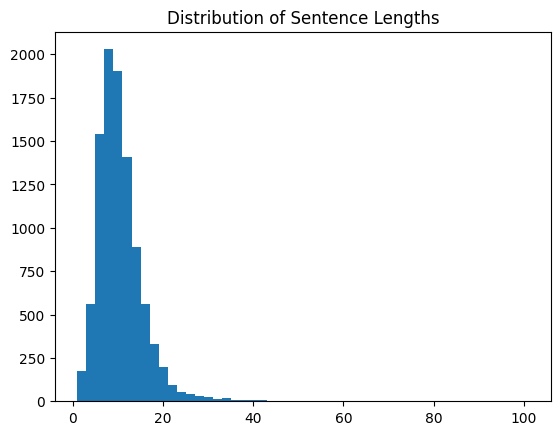

Max Len is 30.0


In [14]:
English_train = df_train['English']
English_train = df_train['Hindi']

eng_lengths = [len(tokenize(s)) for s in English_train]
hin_lengths = [len(tokenize(s)) for s in English_train]


max_len=max(np.percentile(eng_lengths, 99),np.percentile(hin_lengths, 99))+2

print(f"99% of English sentences are shorter than: {np.percentile(eng_lengths, 99)}")
print(f"99% of Hindi sentences are shorter than: {np.percentile(hin_lengths, 99)}")

plt.hist(eng_lengths, bins=50)
plt.title("Distribution of Sentence Lengths")
plt.show()

print(f"Max Len is {max_len}")

Create custom dataset

In [15]:
class TranslationDataset(Dataset):
    def __init__(self, df, English_word2idx, Hindi_word2idx, max_len=20):
        self.df = df
        self.English_word2idx = English_word2idx
        self.Hind_word2idx = Hindi_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def preprocess(self, text, word2idx):
        tokens = tokenize(text)
        indices = [word2idx.get(tok, 1) for tok in tokens]
        indices = [2] + indices + [3]

        if len(indices) < self.max_len:
            indices += [0] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long)

    def __getitem__(self, idx):
        english_text = self.df.iloc[idx]['English']
        hindi_text = self.df.iloc[idx]['Hindi']

        English_tensor = self.preprocess(english_text, self.English_word2idx)
        Hindi_tensor = self.preprocess(hindi_text, self.Hind_word2idx)

        return English_tensor, Hindi_tensor

Loading data into DataLoaders

In [16]:
BATCH_SIZE=64

train_dataset = TranslationDataset(df_train, English_word2idx, Hindi_word2idx, max_len=30)
val_dataset = TranslationDataset(df_val, English_word2idx, Hindi_word2idx, max_len=30)
test_dataset = TranslationDataset(df_test, English_word2idx, Hindi_word2idx, max_len=30)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Varifying that DataLoader and Custom dataset is working fine

In [17]:
English_batch, Hindi_batch = next(iter(train_loader))

print(f"English Batch Shape: {English_batch.shape}")
print(f"Hindi Batch Shape: {Hindi_batch.shape}")

first_sentence = English_batch[0].tolist()
decoded = [English_idx2word.get(idx, '<UNK>') for idx in first_sentence]
print("\nFirst English Sentence in Batch:")
print(" ".join(decoded))

English Batch Shape: torch.Size([64, 30])
Hindi Batch Shape: torch.Size([64, 30])

First English Sentence in Batch:
<SOS> i know skura <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>


Encoder Unit

In [18]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.dropout= nn.Dropout(dropout)

    def forward(self, English_batch):
        embedded = self.dropout(self.embedding(English_batch))
        outputs, hidden = self.rnn(embedded)

        return hidden

Decoder

In [19]:
class Decoder(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, num_layers, dropout, pretrained_embeddings):
        super().__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False)
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden

Seq2Seq Model

In [20]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        
        self.encoder = encoder 
        self.decoder = decoder
        self.device = device

    def forward(self, English_batch, Hindi_batch, tfr=0.5):
        batch_size = English_batch.shape[0]
        Hindi_len = Hindi_batch.shape[1]
        Hindi_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, Hindi_len, Hindi_vocab_size).to(self.device)
        hidden = self.encoder(English_batch)
        input = Hindi_batch[:, 0]

        for t in range(1, Hindi_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t, :] = output
            
            teacher_force = random.random() < tfr
            top_1 = output.argmax(1) 
            input = Hindi_batch[:, t] if teacher_force else top_1

        return outputs

In [21]:
def calculate_accuracy(preds, y, pad_idx):
    top_preds = preds.argmax(1, keepdim=True).squeeze(1)
    
    correct = top_preds.eq(y)
    
    mask = (y != pad_idx)
    correct = correct & mask
    
    accuracy = correct.sum().float() / mask.sum().float()
    return accuracy

In [22]:
def evaluate(model, val_loader, criterion):
    model.eval() 
    epoch_loss = 0
    epoch_acc = 0
    
    with torch.no_grad(): 
        for English_batch, Hindi_batch in val_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)
            
            output = model(English_batch, Hindi_batch, 0) 
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)
            
            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(val_loader), epoch_acc / len(val_loader)

Traning Loop

In [23]:
clip = 1
epoches = 20
hidden_dim = 1024
num_layers = 2
dropout = 0.4
lr=0.001
Hindi_vocab_size = len(Hindi_word2idx) 

encoder = Encoder(embedding_dim, hidden_dim, num_layers, dropout, English_embedding_matrix).to(device)
decoder = Decoder(embedding_dim, Hindi_vocab_size, hidden_dim, num_layers, dropout, Hindi_embedding_matrix).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = optim.Adam(model.parameters(), lr)
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 3. Start MLflow Run
mlflow.set_experiment("Language_Translation_RNN_base")
with mlflow.start_run(run_name="only_RNN_run_4"):
    
    # Log hyperparameters
    mlflow.log_params({
        "epochs": epoches,
        "hidden_dim": hidden_dim,
        "num_layers": num_layers,
        "dropout": dropout,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": lr
    })

    for epoch in range(epoches):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0

        for English_batch, Hindi_batch in train_loader:
            English_batch, Hindi_batch = English_batch.to(device), Hindi_batch.to(device)

            optimizer.zero_grad()
            output = model(English_batch, Hindi_batch)

            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            Hindi_batch = Hindi_batch[:, 1:].reshape(-1)

            loss = criterion(output, Hindi_batch)
            acc = calculate_accuracy(output, Hindi_batch, 0)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc += acc.item()

        train_loss = epoch_loss / len(train_loader)
        train_acc = epoch_acc / len(train_loader)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        # Log metrics to DagsHub MLflow per epoch
        mlflow.log_metrics({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        }, step=epoch)

        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    with open("model_architecture.txt", "w") as f:
        f.write(str(model))
    mlflow.log_artifact("model_architecture.txt")
    
    # 2. Save the fully trained PyTorch model to DagsHub
    mlflow.pytorch.log_model(model, "pytorch_model")

Epoch 01 | Train Loss: 4.1876 | Train Acc: 0.1394 | Val Loss: 4.1112 | Val Acc: 0.1399
Epoch 02 | Train Loss: 4.0920 | Train Acc: 0.1452 | Val Loss: 4.1365 | Val Acc: 0.1288
Epoch 03 | Train Loss: 4.0747 | Train Acc: 0.1488 | Val Loss: 4.1269 | Val Acc: 0.1394
Epoch 04 | Train Loss: 4.0699 | Train Acc: 0.1482 | Val Loss: 4.1100 | Val Acc: 0.1374
Epoch 05 | Train Loss: 4.0507 | Train Acc: 0.1561 | Val Loss: 4.1202 | Val Acc: 0.1439
Epoch 06 | Train Loss: 4.0329 | Train Acc: 0.1638 | Val Loss: 4.1284 | Val Acc: 0.1407
Epoch 07 | Train Loss: 4.0333 | Train Acc: 0.1617 | Val Loss: 4.1257 | Val Acc: 0.1443
Epoch 08 | Train Loss: 4.0206 | Train Acc: 0.1639 | Val Loss: 4.1379 | Val Acc: 0.1290
Epoch 09 | Train Loss: 4.0146 | Train Acc: 0.1660 | Val Loss: 4.1563 | Val Acc: 0.1375
Epoch 10 | Train Loss: 3.9945 | Train Acc: 0.1698 | Val Loss: 4.1311 | Val Acc: 0.1351
Epoch 11 | Train Loss: 3.9798 | Train Acc: 0.1705 | Val Loss: 4.1240 | Val Acc: 0.1350
Epoch 12 | Train Loss: 3.9908 | Train Acc: 

2026/03/27 18:54:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 18:54:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/27 18:54:39 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/27 18:54:50 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128).

🏃 View run only_RNN_run_4 at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/1/runs/738ee63ee8674fc8b2411234b52f8321
🧪 View experiment at: https://dagshub.com/thanwal/Language-Translation.mlflow/#/experiments/1


In [26]:
def translate_sentence(sentence, model, English_word2idx, Hindi_idx2word, device, max_len=30):
    model.eval() 
    
    if isinstance(sentence, str):
        tokens = tokenize(sentence.lower())
    else:
        tokens = [word.lower() for word in sentence]
        
    indices = [English_word2idx.get(tok, 1) for tok in tokens] 
    indices = [2] + indices + [3] 
    
    English_tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        hidden = model.encoder(English_tensor)
        
    Hindi_indexes = [2] 
    
    for i in range(max_len):
        trg_tensor = torch.tensor([Hindi_indexes[-1]], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output, hidden = model.decoder(trg_tensor, hidden)
            
        pred_token = output.argmax(1).item()
        Hindi_indexes.append(pred_token)
        
        if pred_token == 3:
            break
            
    trg_tokens = [Hindi_idx2word.get(i, '<UNK>') for i in Hindi_indexes]
    
    return " ".join(trg_tokens[1:-1])

In [27]:
test_indices = random.sample(range(len(df_test)), 10)

for idx in test_indices:
    src_sentence = df_test.iloc[idx]['English']
    true_translation = df_test.iloc[idx]['Hindi']
    
    model_prediction = translate_sentence(
        src_sentence, model, English_word2idx, Hindi_idx2word, device
    )
    
    print(f"English: {src_sentence}")
    print(f"Actual : {true_translation}")
    print(f"Model  : {model_prediction}")
    print("-" * 50)

English: Tom looked again.
Actual : टॉम ने फिर देखा।
Model  : म म क क क क य
--------------------------------------------------
English: Open an account.
Actual : खाता खोलें।
Model  : म म क क क क य
--------------------------------------------------
English: Evidence has been destroyed.
Actual : सबूत नष्ट हो गया है।
Model  : म म क क क क य
--------------------------------------------------
English: I don't know why Tom didn't do it.
Actual : पता नहीं टॉम ने क्यों नहीं किया।
Model  : म म क क क क य
--------------------------------------------------
English: I found the cage empty.
Actual : मुझे पिंजरा खाली मिला।
Model  : म म क क क क य
--------------------------------------------------
English: Maybe I am unhappy, but I don't intend to kill myself.
Actual : हाँ शायद मैं दुखी हूँ, पर मुझे अपनी जान लेने का इरादा नहीं है।
Model  : म म क क क क य
--------------------------------------------------
English: This phone has a quad-core processor.
Actual : इस फ़ोन में एक क्वाड-कोर प्रोसेसर है।
Model  